## Using numpy to cluster data

### Getting the data

In [125]:
%pip install numpy
%pip install pandas
%pip install matplotlib
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [126]:
import os
import numpy as np

In [127]:
def get_data():
    data_set_1_file = "data/cluster_data_set_2d.csv"
    data_labels_1_file = "data/cluster_data_set_2d_labels.csv"
    test_data_set_1_file = "data/cluster_test_data_set_2d.csv"
    test_data_labels_1_file = "data/cluster_test_data_set_2d_labels.csv"
    data_set_1 = np.loadtxt(data_set_1_file, delimiter=',', skiprows=1)
    data_labels_1 = np.loadtxt(data_labels_1_file, delimiter=',', skiprows=1, )
    test_data_set_1 = np.loadtxt(test_data_set_1_file, delimiter=',', skiprows=1)
    test_data_labels_1 = np.loadtxt(test_data_labels_1_file, delimiter=',', skiprows=1)
    return data_set_1,data_labels_1, test_data_set_1, test_data_labels_1

In [128]:
data_set_1,data_labels_1, test_data_set_1, test_data_labels_1=get_data()

In [129]:
from numpy_clustering_functions import leader_clustering

In [130]:
def perform_leader_clustering(data_set, cluster_results):
    # Perform leader clustering
    try:
        for threshold in np.array([0.8, 1.4, 2.0, 3.0, 4.0]):
            print(f"Clustering with threshold {threshold}")
            c1, l1 = leader_clustering(data_set, threshold)
            print(f"Clustering with threshold {threshold} completed")
            print(f"Number of clusters: {len(np.unique(l1))}")
            r = {'type': 'leader', 'parameter': threshold,'num_of_clusters':len(c1), 'clusters': c1.copy(), 'labels': l1.copy()}
            cluster_results.append(r)
        return cluster_results
    except Exception as e:
        print("Unable to perform leader clustering", e)

In [131]:
cluster_results=[]
cluster_results=perform_leader_clustering(data_set_1, cluster_results)

Clustering with threshold 0.8
Clustering with threshold 0.8 completed
Number of clusters: 22
Clustering with threshold 1.4
Clustering with threshold 1.4 completed
Number of clusters: 11
Clustering with threshold 2.0
Clustering with threshold 2.0 completed
Number of clusters: 6
Clustering with threshold 3.0
Clustering with threshold 3.0 completed
Number of clusters: 3
Clustering with threshold 4.0
Clustering with threshold 4.0 completed
Number of clusters: 2


In [132]:
from numpy_clustering_functions import kmeans_clustering

In [133]:
def perform_k_means_clustering(data_set_1, clluster_results):
    # perform k-means clustering
    try:
        for n_clusters in np.array([2, 3, 4, 5, 6]):
            print(f"Clustering with {n_clusters} clusters")
            c1, l1 = kmeans_clustering(data_set_1, n_clusters)
            print(f"Clustering with {n_clusters} clusters completed")
            print(f"Number of clusters: {len(np.unique(l1))}")
            r = {'type': 'k-means', 'parameter': n_clusters,'num_of_clusters':n_clusters, 'clusters': c1.copy(), 'labels': l1.copy()}
            cluster_results.append(r)
        return cluster_results
    except Exception as e:
        print("Unable to perform k-means clustering", e)

In [134]:
cluster_results=perform_k_means_clustering(data_set_1, cluster_results)

Clustering with 2 clusters
Clustering with 2 clusters completed
Number of clusters: 2
Clustering with 3 clusters
Clustering with 3 clusters completed
Number of clusters: 3
Clustering with 4 clusters
Clustering with 4 clusters completed
Number of clusters: 4
Clustering with 5 clusters
Clustering with 5 clusters completed
Number of clusters: 5
Clustering with 6 clusters
Clustering with 6 clusters completed
Number of clusters: 6


In [135]:
from numpy_clustering_functions import intra_cluster_distance, inter_cluster_distance

In [136]:
def check_performance(cluster_results):
    for c in cluster_results:
        c['intra'] = intra_cluster_distance(data_set_1, c['labels'], c['clusters'])
        c['inter'] = inter_cluster_distance(data_set_1, c['labels'], c['clusters'])
    performance_ready = True if len(cluster_results) == 10 else False
    for i,c in enumerate(cluster_results):
        if 'intra' not in c.keys() or 'inter' not in c.keys():
            print(f"The clustering result {c['type']}/{c['parameter']} does not contain the expected fields.")
            performance_ready = False
        else:
            print(f"id={i} number_of_clusters={c['num_of_clusters']}: The clustering result {c['type']}/{c['parameter']} - intra = {c['intra']} - inter = {c['inter']}")

    if not performance_ready:
        print("Not all clustering results contain the expected fields. Please check the implementation.")


In [137]:
check_performance(cluster_results)

id=0 number_of_clusters=22: The clustering result leader/0.8 - intra = [0.40274737 0.39318375] - inter = 6.950679203184295
id=1 number_of_clusters=11: The clustering result leader/1.4 - intra = [0.69137754 0.70337268] - inter = 7.041770957244185
id=2 number_of_clusters=6: The clustering result leader/2.0 - intra = [1.00921588 0.79722517] - inter = 7.2805364223114974
id=3 number_of_clusters=3: The clustering result leader/3.0 - intra = [1.3301447 1.2934942] - inter = 9.265631632918506
id=4 number_of_clusters=2: The clustering result leader/4.0 - intra = [1.32041756 2.02263503] - inter = 13.653398925599891
id=5 number_of_clusters=2: The clustering result k-means/2 - intra = [0.85544595 1.59464061] - inter = 10.637643280592766
id=6 number_of_clusters=3: The clustering result k-means/3 - intra = [0.84380421 0.72423708] - inter = 8.697064880406062
id=7 number_of_clusters=4: The clustering result k-means/4 - intra = [0.82154902 0.62516768] - inter = 5.3873145828754465
id=8 number_of_clusters

In [138]:
from numpy_clustering_functions import intra_cluster_distance, inter_cluster_distance, assign_data_to_cluster

In [139]:
def select_cluster_from_cluster_results_by_id(id, cluster_results, test_data_set_1):
    selected_cluster = cluster_results[id]
    test_cluster_result = {
        'type': selected_cluster['type'],
        'parameter': selected_cluster['parameter'],
        'clusters': selected_cluster['clusters'].copy()
    }
    test_cluster_result['labels'] = assign_data_to_cluster(test_data_set_1, selected_cluster['clusters'])
    test_cluster_result['intra'] = intra_cluster_distance(test_data_set_1, test_cluster_result['labels'], selected_cluster['clusters'])
    test_cluster_result['inter'] = inter_cluster_distance(test_data_set_1, test_cluster_result['labels'], selected_cluster['clusters'])
    return test_cluster_result, selected_cluster


In [140]:
test_cluster_result, selected_cluster=select_cluster_from_cluster_results_by_id(6,cluster_results, test_data_set_1)
other_test_cluster_result, other_selected_cluster=select_cluster_from_cluster_results_by_id(7,cluster_results, test_data_set_1)

In [141]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [ ]:
def visualize_cluster(selected_cluster,ax, data_set_1, data_labels_1):
    #df_centers = pd.DataFrame(selected_cluster['clusters'], columns=['x','y'])
    #df_clustered = pd.concat([pd.DataFrame(data_set_1, columns=['x','y']), pd.DataFrame(selected_cluster['labels'], columns=['cluster'])], axis=1)
    #ax.scatter(df_clustered, marker='o')
    #print(selected_cluster['clusters'])
    #cluster_labels = data_labels_1
    cluster_labels=selected_cluster['labels']
    print(cluster_labels)
    colormap = np.array(['y','r', 'g', 'b'])
    

    print(data_set_1)
    ax.scatter(data_set_1[:,0],data_set_1[:,1], c=colormap[cluster_labels], marker='o', label="")
    ax.scatter(selected_cluster['clusters'][:,0],selected_cluster['clusters'][:,1], marker='^', color='black')
    ax.legend()
    #ax.title(f"Clustering data set with {selected_cluster['type']}, number of clusters {selected_cluster['parameter']}")
    return ax

[1 3 1 2 1 3 1 1 2 3 1 1 1 2 2 1 1 3 2 1 2 2 3 2 1 1 2 3 3 3 1 2 1 3 2 3 2
 1 3 2 3 2 1 3 2 3 3 3 3 1 2 3 2 3 1 3 1 2 2 2 3 3 1 3 1 1 2 1 3 3 3 3 3 2
 3 3 2 2 2 2 1 1 1 1 2 1 3 2 3 1 1 3 1 3 1 1 1 3 3 2 2 1 2 2 1 3 1 3 1 1 2
 2 1 2 3 2 3 1 3 2 1 3 2 3 3 1 2 2 3 3 1 2 2 3 1 3 2 2 1 3 3 2 3 1 2 2 1 1
 1 3 2 2 2 2 1 3 3 1 3 1 2 2 3 2 2 1 3 1 3 2 2 2 3 1 1 2 1 2 1 3]
[[ 7.29825374e+00 -2.47107020e+00]
 [ 8.41205536e+00  8.55728711e-01]
 [ 6.88664333e+00 -3.80323796e+00]
 [ 1.36495746e+00  6.75963472e+00]
 [ 7.09621997e+00 -2.14222218e+00]
 [ 6.20427044e+00  2.34130584e+00]
 [ 7.93513455e+00 -1.57103896e+00]
 [ 5.67334180e+00 -1.68527151e+00]
 [ 2.96277469e+00  4.76562598e+00]
 [ 2.53665394e+00  5.00392846e-01]
 [ 8.05290014e+00 -1.62361080e+00]
 [ 6.79740819e+00 -2.92773869e+00]
 [ 5.20163431e+00 -3.73075066e+00]
 [ 2.06450843e+00  5.22725810e+00]
 [ 1.69924578e+00  5.14465748e+00]
 [ 8.46964343e+00 -2.54681133e+00]
 [ 5.29979073e+00 -2.56989139e+00]
 [ 4.98995199e+00  6.93494973e-01]
 [ 3

C:\Users\wilfr\AppData\Local\Temp\ipykernel_6972\2597279159.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


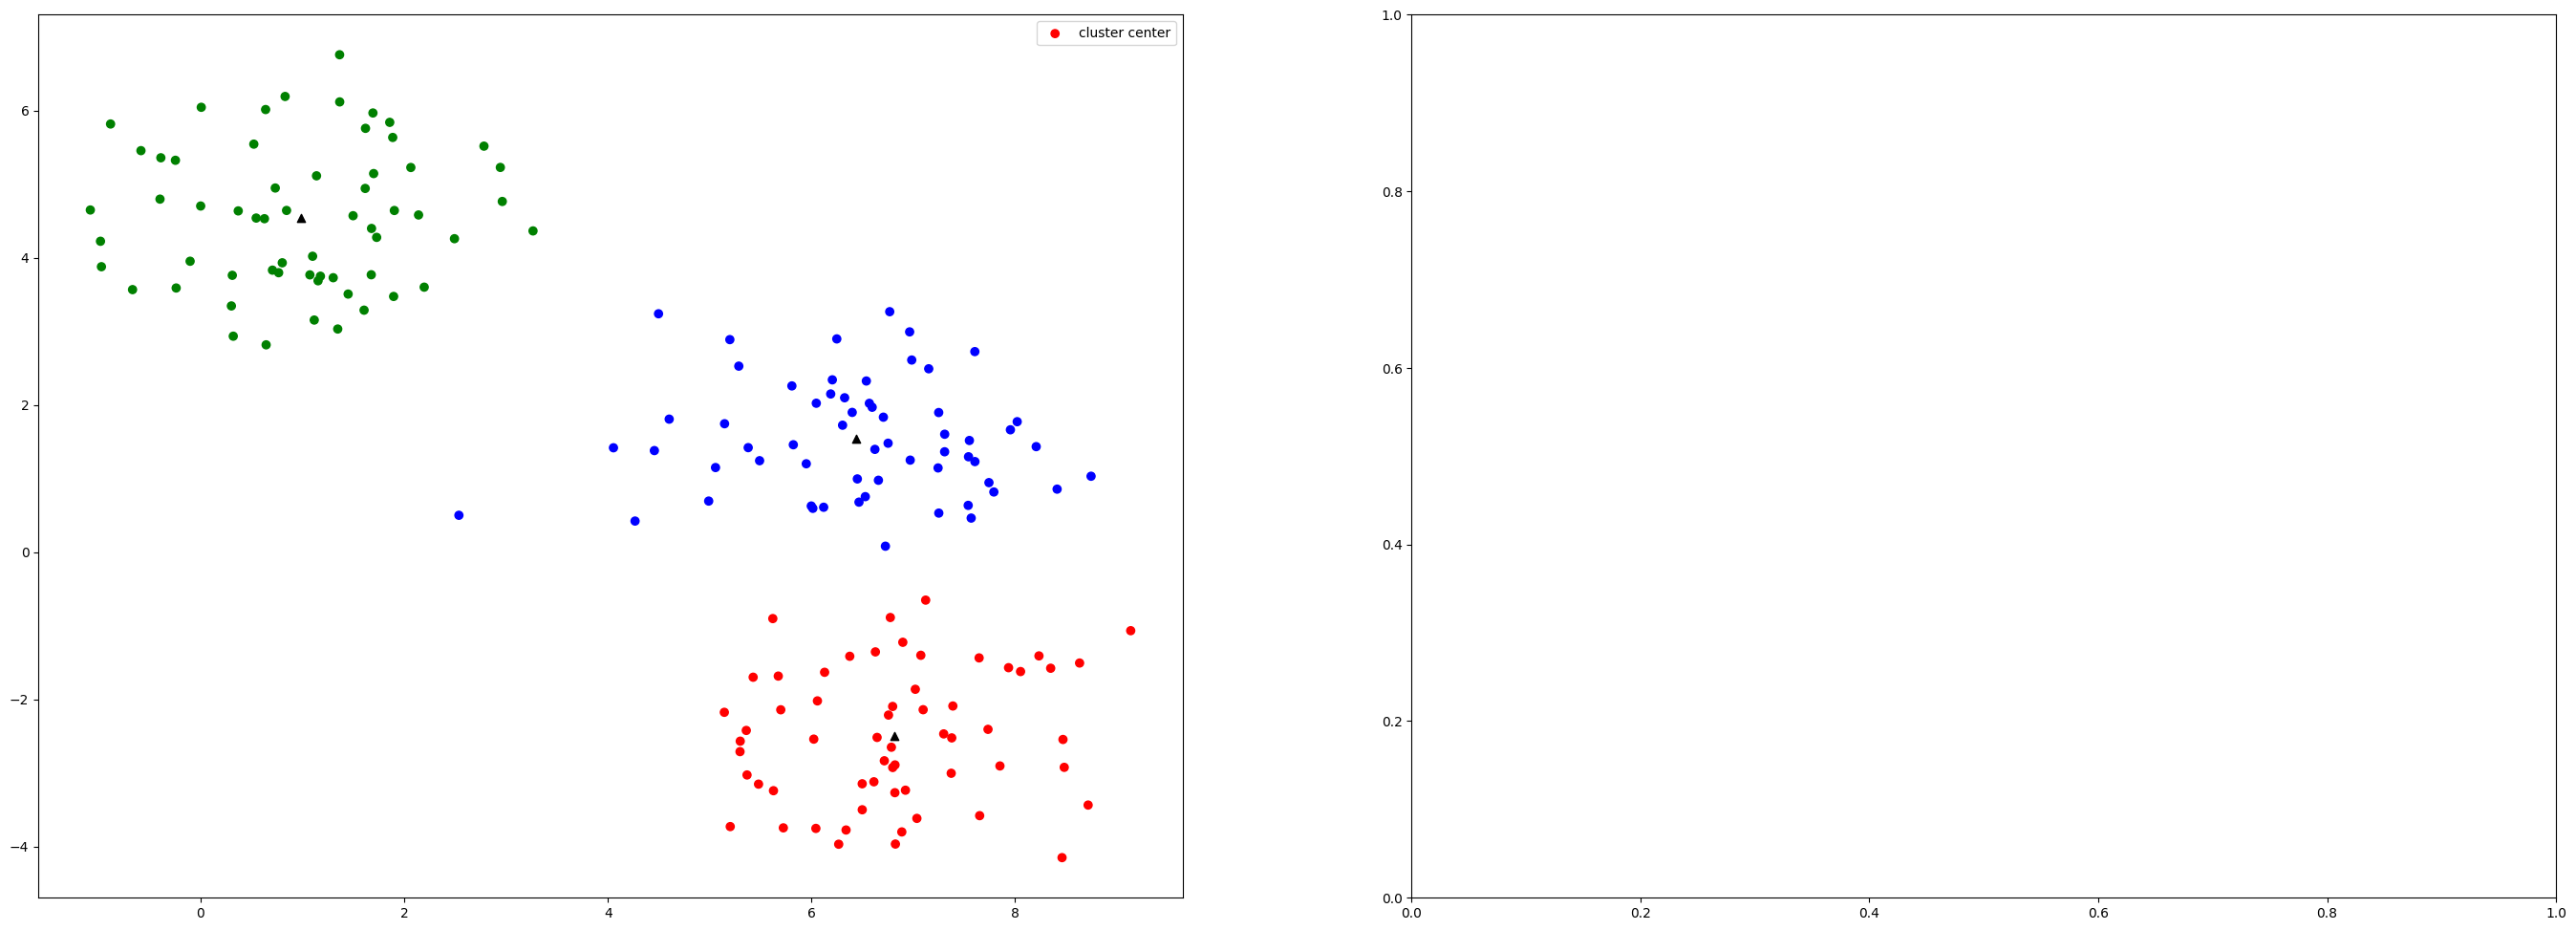

In [205]:
fig, ax = plt.subplots(1, 2, figsize=(34, 12))
ax[0]=visualize_cluster(test_cluster_result, ax[0], data_set_1, data_labels_1)
fig.show()

In [ ]:
def visualize_cluster(selected_cluster, test_cluster_result):
    if selected_cluster is None or test_cluster_result is None:
        print("No selected clustering result found. Skipping visualisation steps.")
    else:
        print(f"Selected clustering result: {test_cluster_result}")

    df_centers = pd.DataFrame(selected_cluster['clusters'], columns=['x','y'], index=[0,1,2])
    #df_train = pd.concat([pd.DataFrame(data_set_1, columns=['x','y']), pd.DataFrame(data_labels_1, columns=['cluster'])], axis=1)
    df_clustered = pd.concat([pd.DataFrame(data_set_1, columns=['x','y']), pd.DataFrame(selected_cluster['labels'], columns=['cluster'])], axis=1)
    #sns.scatterplot(data=df_train, x='x', y='y', hue='cluster' , palette="tab10", alpha=0.4)
    sns.scatterplot(data=df_clustered, x='x', y='y', hue='cluster' , palette="tab10", marker='x')
    sns.scatterplot(data=df_centers, x='x', y='y', c="k", marker='^', label="cluster center")
    plt.title(f"Clustering data set with {selected_cluster['type']}/{selected_cluster['parameter']}")
    plt.show(block=True)

    df_test_clustered = pd.concat([pd.DataFrame(test_data_set_1, columns=['x','y']), pd.DataFrame(test_cluster_result['labels'], columns=['cluster'])], axis=1)
    df_test = pd.concat([pd.DataFrame(test_data_set_1, columns=['x','y']), pd.DataFrame(test_data_labels_1, columns=['cluster'])], axis=1)
    sns.scatterplot(data=df_test, x='x', y='y', hue='cluster' , palette="tab10", alpha=0.4)
    sns.scatterplot(data=df_test_clustered, x='x', y='y', hue='cluster' , palette="tab10", marker='x')
    sns.scatterplot(data=df_centers, x='x', y='y', c="k", marker='^', label="cluster center")
    plt.title(f"Clustering test set with {selected_cluster['type']}/{selected_cluster['parameter']}")
    plt.show(block=True)

Selected clustering result: {'type': 'k-means', 'parameter': np.int64(3), 'clusters': array([[ 6.69379992, -0.54882609],
       [ 0.91441994,  5.35278759],
       [ 1.32073065,  3.65116043]]), 'labels': array([0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 1,
       2, 0, 0, 0, 0, 1, 1, 2, 2, 0, 1, 0, 0, 1, 2, 0, 2, 0, 0, 2, 0, 0,
       1, 2, 2, 2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 1, 0, 0, 0, 0]), 'intra': array([0.84159629, 1.33167748]), 'inter': np.float64(8.891281048781318)}


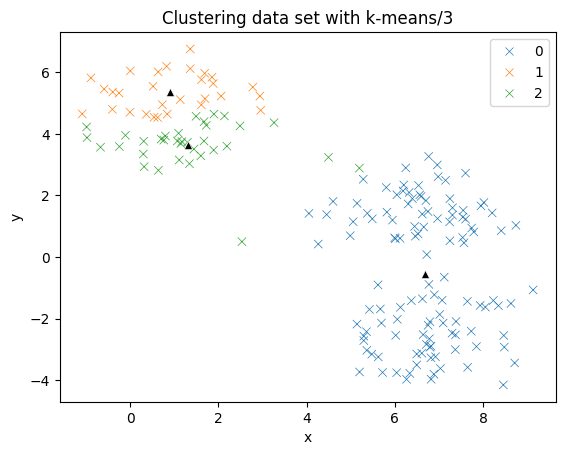

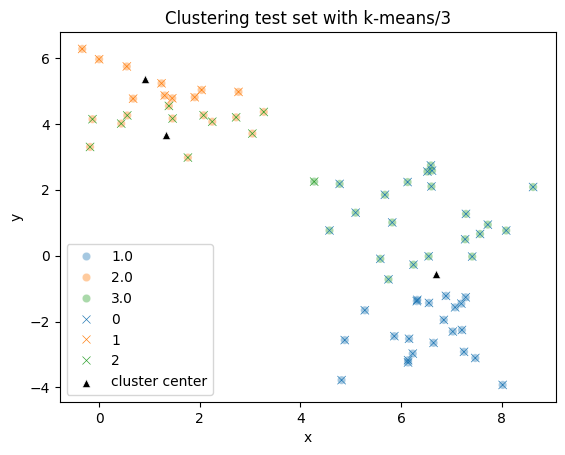

In [ ]:
visualize_cluster(selected_cluster,test_cluster_result)